# CreditWise Loan System

Built an end-to-end supervised ML pipeline using KNN , Logistic-Regression and Naive-Bayes to predict loan approval.
Implemented Binary classification along with EDA , feature engineerong & model evaluation(Precision , Recall , F1)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score

In [3]:
df = pd.read_csv("../data/loan_approval_data.csv")

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handle Missing Values

In [5]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["float64"]).columns

In [6]:
from sklearn.impute import SimpleImputer # SimpleImputer is used to fill NAN values on the basis of data mean , avg , median

num_imp = SimpleImputer(strategy = "mean")
cat_imp = SimpleImputer(strategy = "most_frequent")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [7]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [8]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Text(0.5, 1.0, 'Is Loan Approved or Not ?')

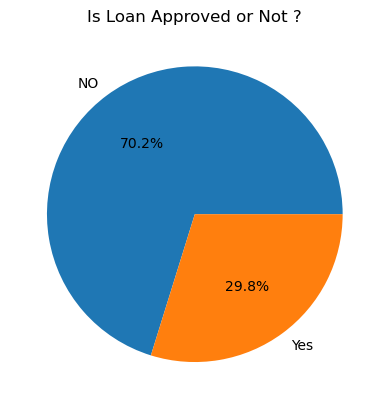

In [9]:
# How balanced our classes are ?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count , labels=["NO","Yes"] , autopct="%1.1f%%")
plt.title("Is Loan Approved or Not ?")

<Axes: xlabel='Gender', ylabel='count'>

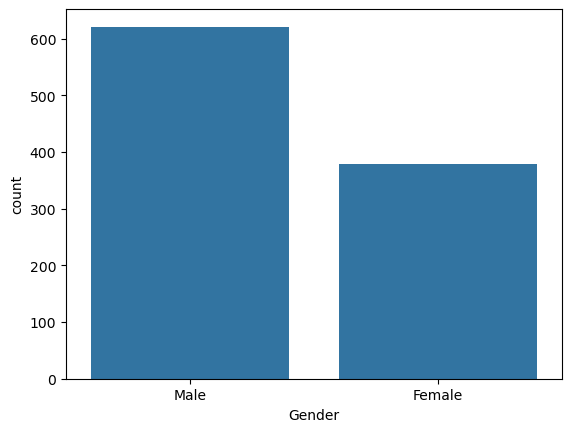

In [10]:
# Analyzing Categories

gender_count = df["Gender"].value_counts()
sns.barplot(gender_count)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

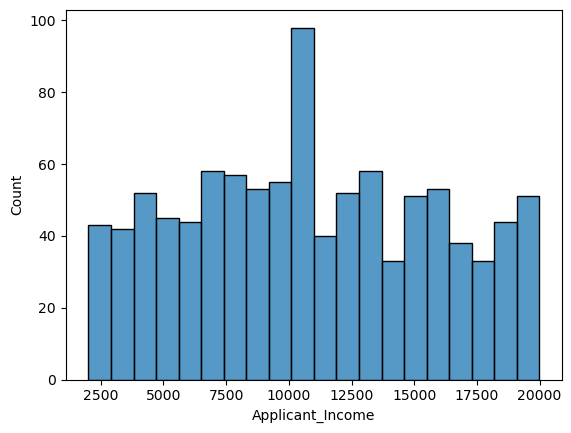

In [11]:
# Analyze applicant income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

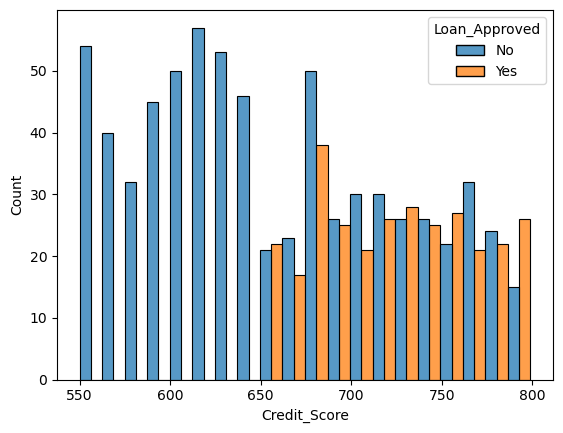

In [12]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

# for analyzing outliers , we use BoxPlot

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

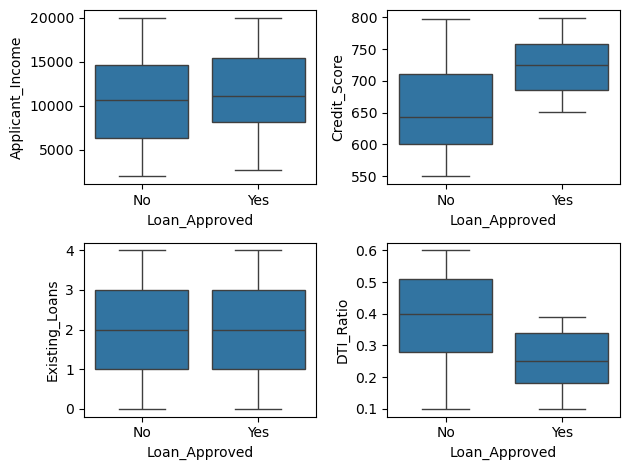

In [13]:
fig , axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0] , data=df , x="Loan_Approved" , y="Applicant_Income")
sns.boxplot(ax=axes[0,1] , data=df , x="Loan_Approved" , y="Credit_Score")
sns.boxplot(ax=axes[1,0] , data=df , x="Loan_Approved" , y="Existing_Loans")
sns.boxplot(ax=axes[1,1] , data=df , x="Loan_Approved" , y="DTI_Ratio")
plt.tight_layout()

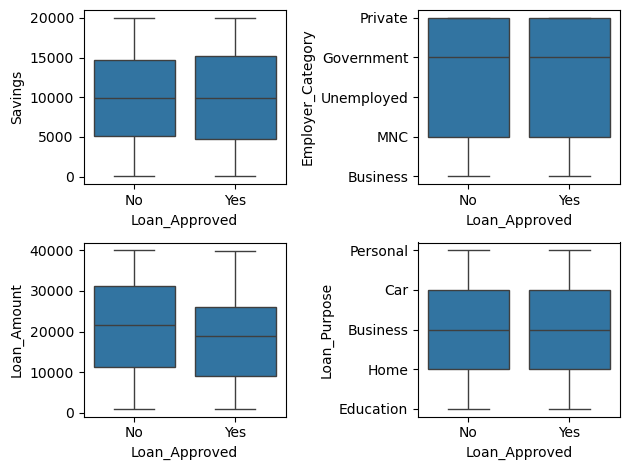

In [14]:
fig , axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0] , data=df , x="Loan_Approved" , y="Savings")
sns.boxplot(ax=axes[0,1] , data=df , x="Loan_Approved" , y="Employer_Category")
sns.boxplot(ax=axes[1,0] , data=df , x="Loan_Approved" , y="Loan_Amount")
sns.boxplot(ax=axes[1,1] , data=df , x="Loan_Approved" , y="Loan_Purpose")

plt.tight_layout()

# Feature Encoding

In [15]:
#Encoding

#1) LabelEncoder - Assings an integer to each category 
#=> used in ordinal data (where order is matter in data , to prioritize it)
#=> also used for output

#2) OneHotEncoder - Creates binary columns for each category
#=> used in nominal data (where order of data does not matter and each category is at same level)

In [16]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [17]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category","Gender"]
ohe = OneHotEncoder(drop="first" , sparse_output=False , handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded , columns=ohe.get_feature_names_out(cols) , index= df.index)
df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

# Coorelational Heat

<Axes: >

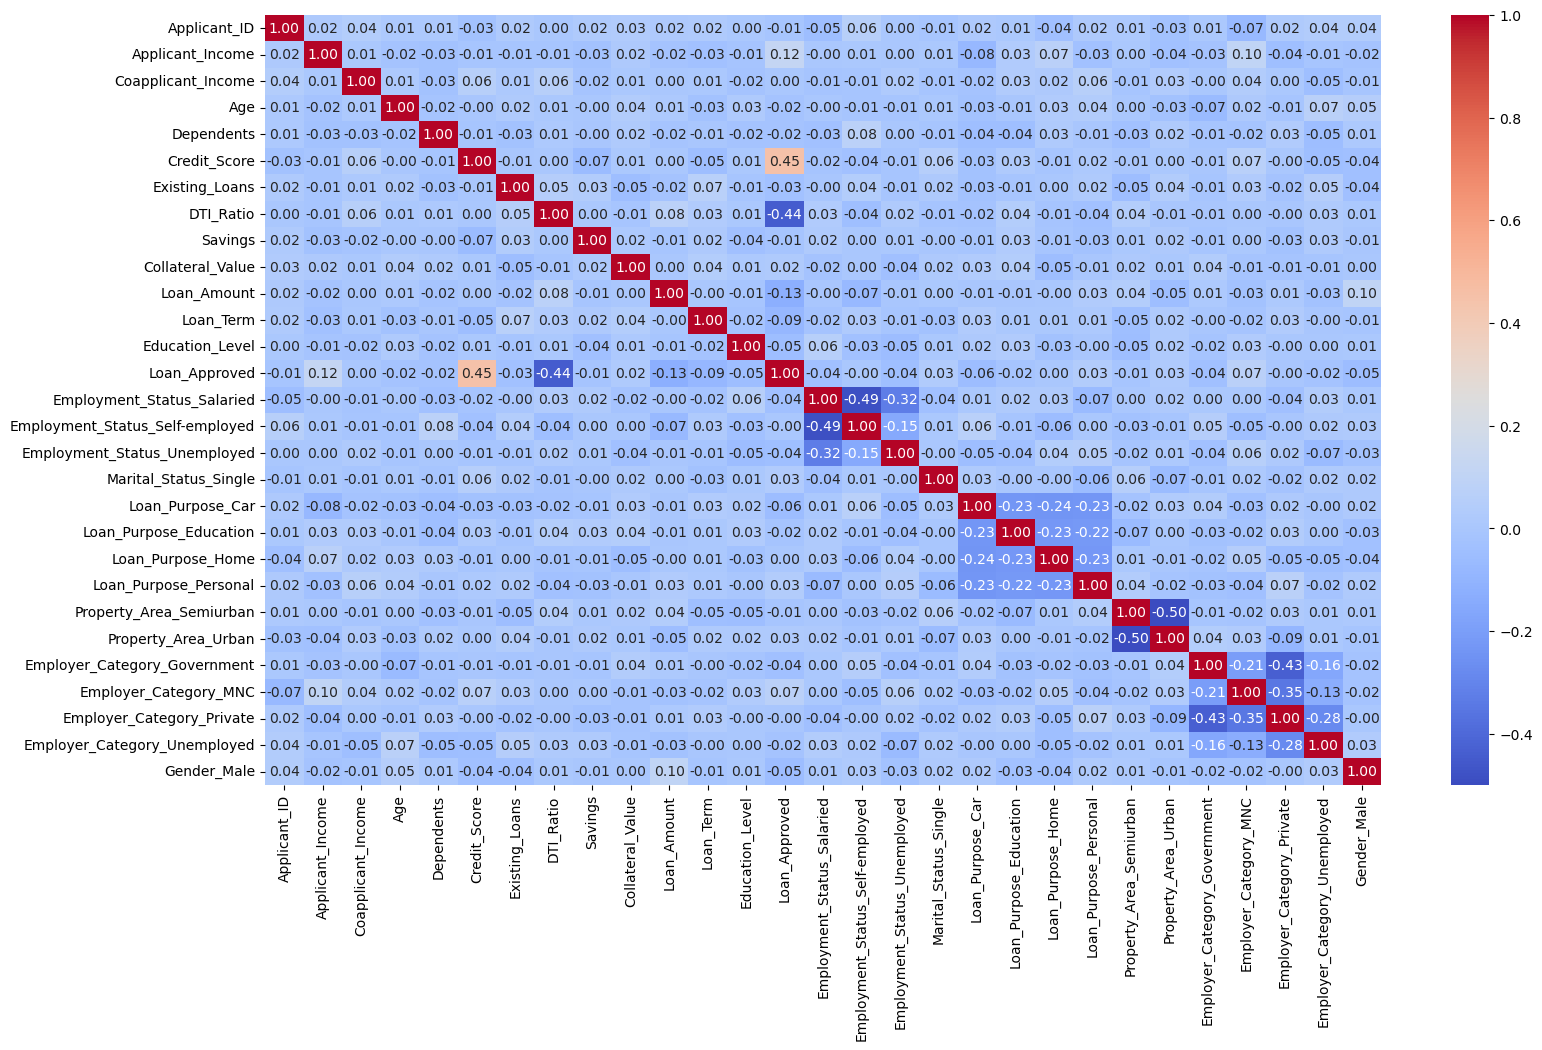

In [18]:
nums_col = df.select_dtypes(include="number")
corr_matrix = nums_col.corr()

plt.figure(figsize=(18,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Train-Test-split and Feature Scaling

In [19]:
X = df.drop("Loan_Approved" , axis=1)
y = df["Loan_Approved"]

In [20]:
X_train , X_test , y_train , y_test = train_test_split (X , y , test_size = 0.2 , random_state = 42)

NameError: name 'train_test_split' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training & Evaluation

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled , y_train)

y_pred = lr_model.predict(X_test_scaled)

# Evaluation

print("Logistic Regression")
print("Precision" , precision_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("f1_score" , f1_score(y_test , y_pred))
print("Accuracy" , accuracy_score(y_test , y_pred))
print("Confusion_matrix\n" , confusion_matrix(y_test , y_pred))

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation

print("KNN")
print("Precision" , precision_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("f1_score" , f1_score(y_test , y_pred))
print("Accuracy" , accuracy_score(y_test , y_pred))
print("Confusion_matrix\n" , confusion_matrix(y_test , y_pred))

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation

print("KNN")
print("Precision" , precision_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("f1_score" , f1_score(y_test , y_pred))
print("Accuracy" , accuracy_score(y_test , y_pred))
print("Confusion_matrix\n" , confusion_matrix(y_test , y_pred))

# feature Engineering

In [ ]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"] = df["Credit_Score"]**2

X = df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled , y_train)

y_pred = lr_model.predict(X_test_scaled)

# Evaluation

print("Logistic Regression")
print("Precision" , precision_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("f1_score" , f1_score(y_test , y_pred))
print("Accuracy" , accuracy_score(y_test , y_pred))
print("Confusion_matrix\n" , confusion_matrix(y_test , y_pred))

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation

print("KNN")
print("Precision" , precision_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("f1_score" , f1_score(y_test , y_pred))
print("Accuracy" , accuracy_score(y_test , y_pred))
print("Confusion_matrix\n" , confusion_matrix(y_test , y_pred))

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation

print("KNN")
print("Precision" , precision_score(y_test , y_pred))
print("Recall" , recall_score(y_test , y_pred))
print("f1_score" , f1_score(y_test , y_pred))
print("Accuracy" , accuracy_score(y_test , y_pred))
print("Confusion_matrix\n" , confusion_matrix(y_test , y_pred))